In [11]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
def actionTrajectory(actionArray):
    """
        Returns an array with the (mean) trajectory over actions, with size K x Horizon
    """
    K = np.max(actionArray)
    if actionArray.ndim == 1:
        return (actionArray == np.arange(1,K+1)[:,None]).astype(np.int64)
    if actionArray.ndim == 2:
        pass

In this part, we simulate the following simple bandit algorithm for a 2-armed bandit, with binary rewards having respective probabilities $p_1$ and $p_2$.

## Simple case: one experiment

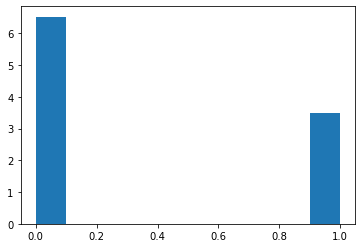

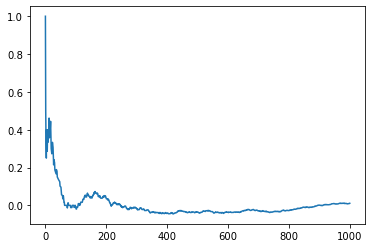

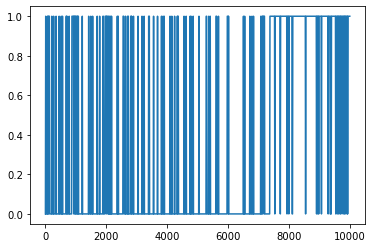

In [14]:
n_arms = 2
mu_vec = np.array([0.6, 0.5])
assert len(mu_vec)== n_arms
horizon = 1000
action = np.empty(horizon,dtype= np.int64) #action
reward = np.empty(horizon) # realized reward
#xMean = np.zeros((2, horizon))

# Initialization: pull each arm once
for k in range(n_arms):
    action[k] = k
    reward[k] = np.random.binomial(1,mu_vec[action[k]])

means = np.empty(n_arms)
def epsGreedy(means, explor_proba= 0.1):
    best_action = np.argmax(means)
    other_actions = [k for k in range(len(means)) if k != best_action]
    explore = bool(np.random.binomial(1, 1-explor_proba))
    if explore: 
        return np.random.choice(other_actions, 1)
    else: 
        return best_action

for t in range(2, horizon):
    # play action
    for k in range(n_arms):
        means[k] = reward[action == k].mean()
    action[t] = epsGreedy(means)

    # observe reward
    reward[t] = np.random.binomial(1,mu_vec[action[t]])


agentCumulReward = np.cumsum(reward)
oraclCumulReward = np.cumsum(np.random.binomial(1, np.max(mu_vec), size= horizon))
meanRegret = (oraclCumulReward - agentCumulReward)/np.arange(1,horizon+1)
plt.figure()
plt.hist(action, density= True)

plt.figure()
plt.plot(meanRegret)
plt.figure()
trajectory = actionTrajectory(action)
plt.plot(np.arange(horizon)*10,action)

## Two arms, multiple simulations

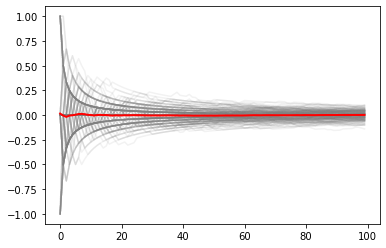

In [5]:
repetitions= 200
p = np.array([0.1, 0.09999999])
horizon = 100
action = np.zeros((horizon, repetitions),dtype=np.int64)
x = np.zeros((horizon, repetitions))
#xMean = np.zeros((2, horizon))

action[0] = 2#np.random.randint(1,3, size= repetitions)
x[0] = np.random.binomial(1,p[action[0]-1])
#xMean[action[0]-1,0] = x[0]
action[1] = 1#np.random.randint(1,3, size= repetitions)
x[1] = np.random.binomial(1,p[action[1]-1])
#xMean[action[1]-1,1] = x[1]

explorProba = 0.1

for t in range(2, horizon):
    exploit = np.random.binomial(1, 1-explorProba, size= repetitions)
    mean1 = np.sum(x*(action==1), axis= 0)/np.sum(action==1,axis= 0)
    mean2 = np.sum(x*(action==2), axis= 0)/np.sum(action==2,axis= 0)
    bestAction = np.argmax(np.vstack((mean1, mean2)), axis= 0) + 1
    action[t, exploit == 1] = bestAction[exploit == 1]
    action[t, exploit == 0] = 3 - bestAction[exploit == 0]
    x[t] = np.random.binomial(1,p[action[t]-1])

agentCumulReward = np.cumsum(x, axis= 0)
oraclCumulReward = np.cumsum(np.random.binomial(1, np.max(p), size= (horizon,repetitions)), axis= 0)
meanRegret = (oraclCumulReward - agentCumulReward)/(np.arange(horizon)[:,None]+1)
#plt.figure()
#plt.hist(action, density= True)

plt.figure()
plt.plot(meanRegret, color= 'gray', alpha= 0.1)
plt.plot(np.mean(meanRegret, axis= 1), color= 'r', linewidth= 2)
#plt.plot(np.median(meanRegret, axis= 1), color= 'y', linewidth= 2)

In [6]:
action.ndim

2

In [7]:
@jit(nopython= True)
def getExploreIndices(n_arms, best_action, exploreLogicInds):
    size= np.sum(exploreLogicInds)
    armIndices = np.arange(arms)
    bestActionForExplor = best_action[exploreLogicInds]
    res = []
    for j in range(size):
        res.append([k for k in armIndices if k != bestActionForExplor[j]-1])
    return res

## Multi-armed, multiple simulations

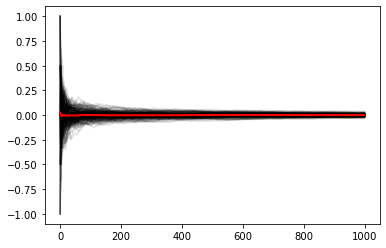

In [8]:
repetitions= 200
p = 0.1*np.array([1,1,1])
arms = len(p)
horizon = 1000
action = np.zeros((horizon, repetitions),dtype=np.int64)
x = np.zeros((horizon, repetitions))
#xMean = np.zeros((2, horizon))

for k in range(arms):
    action[k] = k+1#np.random.randint(1,3, size= repetitions)
    x[k] = np.random.binomial(1,p[action[k]-1])


explorProba = 0.01

for t in range(arms, horizon):
    exploit = np.random.binomial(1, 1-explorProba, size= repetitions)
    meansTuple = tuple(np.sum(x*(action==k), axis= 0)/np.sum(action==k,axis= 0) for k in range(1,arms+1))
    bestAction = np.argmax(np.vstack(meansTuple), axis= 0) + 1
    # in case of exploitation, take the best action
    action[t, exploit == 1] = bestAction[exploit == 1] 
    # in case of exploration, take at random an action that is not the best action
    if any(exploit == 0):
        explorActions = np.array(getExploreIndices(arms, bestAction, exploit == 0))
        choice = np.random.randint(0, arms-1, size= np.sum(exploit == 0))
        action[t, exploit == 0] = explorActions[np.arange(len(explorActions)),choice]
    x[t] = np.random.binomial(1,p[action[t]-1])

agentCumulReward = np.cumsum(x, axis= 0)
oraclCumulReward = np.cumsum(np.random.binomial(1, np.max(p), size= (horizon,repetitions)), axis= 0)
meanRegret = (oraclCumulReward - agentCumulReward)/(np.arange(horizon)[:,None]+1)
#plt.figure()
#plt.hist(action, density= True)

plt.figure()
plt.plot(meanRegret, color= 'k', alpha= 0.1)
plt.plot(np.mean(meanRegret, axis= 1), color= 'r', linewidth= 2)

## Greedy with Gibbs/Boltzmann distribution (softmax probabilities)

7.664312839508057


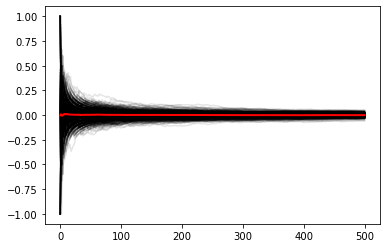

In [9]:
from scipy.special import softmax
repetitions= 500
p = 0.1*np.array([1,1.002,1.001])
arms = len(p)
horizon = 500
assert horizon>=arms, "horizon must be at least equal to the number of arms"
action = np.zeros((horizon, repetitions),dtype=np.int64)
x = np.zeros((horizon, repetitions))
#xMean = np.zeros((2, horizon))

for k in range(arms):
    action[k] = k+1#np.random.randint(1,3, size= repetitions)
    x[k] = np.random.binomial(1,p[action[k]-1])


 # 0 corresponds to pure exploration, infinite to pure exploitation

@jit(nopython= True)
def ArrayMultinomial(probabilities):
    size = probabilities.shape[1]
    res = np.empty(size)
    for i in range(size):
        #res[i] = np.random.choice(probabilities.shape[0], p= probabilities[:,i], size= 1)
        res[i] = np.where(np.random.multinomial(1, probabilities[:,i])>0)[0][0]
    return res
from time import time
start = time()
exploit = 0.1
for t in range(arms, horizon):
    meansTuple = tuple(np.sum(x*(action==k), axis= 0)/np.sum(action==k,axis= 0) for k in range(1,arms+1))
    meansArray = np.vstack(meansTuple)
    selectProbabilities = softmax(exploit*meansArray, axis= 0)
    # in case of exploitation, take the best action
    action[t] = ArrayMultinomial(selectProbabilities)+1
    x[t] = np.random.binomial(1,p[action[t]-1])
end = time()
print(end-start)

agentCumulReward = np.cumsum(x, axis= 0)
oraclCumulReward = np.cumsum(np.random.binomial(1, np.max(p), size= (horizon,repetitions)), axis= 0)
meanRegret = (oraclCumulReward - agentCumulReward)/(np.arange(horizon)[:,None]+1)
#plt.figure()
#plt.hist(action, density= True)

plt.figure()
plt.plot(meanRegret, color= 'k', alpha= 0.1)
plt.plot(np.mean(meanRegret, axis= 1), color= 'r', linewidth= 2)
# for 500x500 experiment, 17s without jit vs 7 for jit